# Imports

In [ ]:
# ! pip install -U datasets
! pip install deepface --quiet
#! pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.4 MB/s eta 0:00:00


In [ ]:
import cv2, polars as pl, matplotlib.pyplot as plt
import os, pickle
from PIL import Image
from deepface import DeepFace

25-10-30 12:29:35 - Directory /root/.deepface has been created
25-10-30 12:29:35 - Directory /root/.deepface/weights has been created


## **Huggingface Key**

In [ ]:
# ! echo "HF_TOKEN=<your token>" > .env
# OR
# ! export HF_TOKEN=<your token>;
# ! cat .env

In [ ]:
### READ FROM LAST SAVED PROGRESS AS A .pickle FILE
file_name = 'results.pickle'

with open(file_name, 'rb') as pfile:
    lfw_race_labels = pickle.load(pfile)
print(results == lfw_race_labels) # confirm they are the same

True


> DeepFace is a hybrid face recognition package. It currently wraps many state-of-the-art face recognition models: VGG-Face , FaceNet, OpenFace, DeepFace, DeepID, ArcFace, Dlib, SFace, GhostFaceNet and Buffalo_L.

<hr/>

# Using the LFW Dataset

In [ ]:
# https://huggingface.co/datasets/bitmind/lfw
# If using the LFW dataset

from datasets import load_dataset
ds = load_dataset("bitmind/lfw")

lfw = ds["train"]

# A way to find which people have at least N number of photos
N = 20
lfw_min20_photos = lfw.filter(lambda x: f'00{N}' in x['filename'] if N < 100 else f'0{N}' in x['filename'])

Filter:   0%|          | 0/13233 [00:00<?, ? examples/s]

2 graphs
- graph #1: the embeddings of the same person's images
- graph #2: the embeddings from graph 1 + other people's embeddings, to see how well they cluster, group up etc.

Dragan_Covic_0001.jpg
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E9A06796450>, 'filename': 'Dragan_Covic_0001.jpg'}


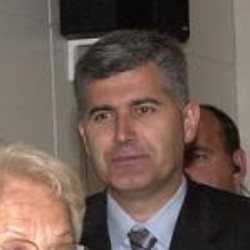

In [ ]:
# How does the data look like?
print(lfw[2]['filename'])
print(lfw[2])
lfw[2]['image']

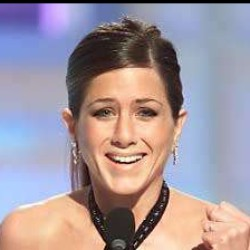

In [ ]:
lfw_min20_photos['image'][0]

Roughly 158 people have 10 images of themselves.

~ 96 people have 15 images of themselves.

~ 62 people have $\geq$ 20 images of themselves.

In [ ]:
person_images = {}
people = [i.split('0')[0] for i in lfw_min20_photos['filename']]  # just extract the names

for person in people:
  person_images[person] = lfw.filter(lambda x: person in x["filename"])[:20] # find all matching images with that name, and cap to 20 for uniformity

In [ ]:
print(person_images)
person_images.keys()

{'Jennifer_Aniston_': {'image': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E61E3F80>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F347D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F346E0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34B60>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34530>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34830>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34B00>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34D10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F34170>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F342C0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250 at 0x7E99E4F346B0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size

dict_keys(['Jennifer_Aniston_', 'Tom_Daschle_', 'Alvaro_Uribe_', 'Angelina_Jolie_', 'Mahmoud_Abbas_', 'Igor_Ivanov_', 'Jiang_Zemin_', 'John_Negroponte_', 'Jacques_Chirac_', 'Rudolph_Giuliani_', 'Gerhard_Schroeder_', 'Jose_Maria_Aznar_', 'Roh_Moo-hyun_', 'Hamid_Karzai_', 'Vladimir_Putin_', 'Jennifer_Lopez_', 'Tony_Blair_', 'Jack_Straw_', 'Pete_Sampras_', 'Amelie_Mauresmo_', 'Bill_Clinton_', 'Nestor_Kirchner_', 'Naomi_Watts_', 'Kofi_Annan_', 'Luiz_Inacio_Lula_da_Silva_', 'Paul_Bremer_', 'Carlos_Menem_', 'Winona_Ryder_', 'Tom_Ridge_', 'Jean_Chretien_', 'Andre_Agassi_', 'David_Beckham_', 'Donald_Rumsfeld_', 'Laura_Bush_', 'Arnold_Schwarzenegger_', 'Juan_Carlos_Ferrero_', 'Colin_Powell_', 'Saddam_Hussein_', 'Ricardo_Lagos_', 'Jeremy_Greenstock_', 'Lindsay_Davenport_', 'Hugo_Chavez_', 'Jennifer_Capriati_', 'Tiger_Woods_', 'Junichiro_Koizumi_', 'Gloria_Macapagal_Arroyo_', 'Alejandro_Toledo_', 'Hans_Blix_', 'Ariel_Sharon_', 'Recep_Tayyip_Erdogan_', 'George_Robertson_', 'Vicente_Fox_', 'George_

In [ ]:
# Save images from dataset to a local format in filesystem (.png),
# as Deepface does not accept PIL
import os

os.mkdir("intra-sim")
for person in person_images.keys():
  images = lfw.filter(lambda x: x["filename"] in person_images[person]['filename'])
  os.mkdir(f'intra-sim/{person}')
  for i, image in enumerate(images):
    image["image"].save(f'intra-sim/{person}/{i+1}.png')

In [ ]:
person_images['Ariel_Sharon_']['filename']

['Ariel_Sharon_0050.jpg',
 'Ariel_Sharon_0044.jpg',
 'Ariel_Sharon_0045.jpg',
 'Ariel_Sharon_0051.jpg',
 'Ariel_Sharon_0047.jpg',
 'Ariel_Sharon_0053.jpg',
 'Ariel_Sharon_0052.jpg',
 'Ariel_Sharon_0046.jpg',
 'Ariel_Sharon_0042.jpg',
 'Ariel_Sharon_0056.jpg',
 'Ariel_Sharon_0057.jpg',
 'Ariel_Sharon_0043.jpg',
 'Ariel_Sharon_0055.jpg',
 'Ariel_Sharon_0041.jpg',
 'Ariel_Sharon_0069.jpg',
 'Ariel_Sharon_0068.jpg',
 'Ariel_Sharon_0040.jpg',
 'Ariel_Sharon_0054.jpg',
 'Ariel_Sharon_0033.jpg',
 'Ariel_Sharon_0027.jpg']

In [ ]:
model = "Facenet512"
lfw_embedded = {}

for person in person_images.keys():
  for i, image in enumerate(person_images[person]['filename']):
    try:
      lfw_embedded[image] = DeepFace.represent(f'intra-sim/{person}/{i+1}.png', model_name=model) # VGGFace by default
    except ValueError:
      print(f"error with image >>", image) # here, detection phase was unsuccessful
      lfw_embedded[image] = None

25-10-30 13:17:51 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /root/.deepface/weights/facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /root/.deepface/weights/facenet512_weights.h5
100%|██████████| 95.0M/95.0M [00:01<00:00, 49.9MB/s]


error with image >> Angelina_Jolie_0012.jpg
error with image >> Angelina_Jolie_0017.jpg
error with image >> Mahmoud_Abbas_0006.jpg
error with image >> Igor_Ivanov_0007.jpg
error with image >> Jiang_Zemin_0002.jpg
error with image >> Jiang_Zemin_0016.jpg
error with image >> Jacques_Chirac_0021.jpg
error with image >> Hamid_Karzai_0009.jpg
error with image >> Pete_Sampras_0015.jpg
error with image >> Kofi_Annan_0019.jpg
error with image >> Luiz_Inacio_Lula_da_Silva_0032.jpg
error with image >> Laura_Bush_0019.jpg
error with image >> Arnold_Schwarzenegger_0036.jpg
error with image >> Ricardo_Lagos_0005.jpg
error with image >> Lindsay_Davenport_0015.jpg
error with image >> Jennifer_Capriati_0017.jpg
error with image >> Jennifer_Capriati_0005.jpg
error with image >> Hans_Blix_0024.jpg
error with image >> Hans_Blix_0030.jpg
error with image >> Ariel_Sharon_0046.jpg
error with image >> Silvio_Berlusconi_0015.jpg
error with image >> Michael_Bloomberg_0014.jpg
error with image >> Atal_Bihari_Va

In [ ]:
# lfw_embedded['Alejandro_Toledo_0001.jpg'][0]['embedding']

In [ ]:
# len(lfw_embedded) # 30 images could not be converted to embedd.

1240

In [ ]:
person_images.keys()

dict_keys(['Jennifer_Aniston_', 'Tom_Daschle_', 'Alvaro_Uribe_', 'Angelina_Jolie_', 'Mahmoud_Abbas_', 'Igor_Ivanov_', 'Jiang_Zemin_', 'John_Negroponte_', 'Jacques_Chirac_', 'Rudolph_Giuliani_', 'Gerhard_Schroeder_', 'Jose_Maria_Aznar_', 'Roh_Moo-hyun_', 'Hamid_Karzai_', 'Vladimir_Putin_', 'Jennifer_Lopez_', 'Tony_Blair_', 'Jack_Straw_', 'Pete_Sampras_', 'Amelie_Mauresmo_', 'Bill_Clinton_', 'Nestor_Kirchner_', 'Naomi_Watts_', 'Kofi_Annan_', 'Luiz_Inacio_Lula_da_Silva_', 'Paul_Bremer_', 'Carlos_Menem_', 'Winona_Ryder_', 'Tom_Ridge_', 'Jean_Chretien_', 'Andre_Agassi_', 'David_Beckham_', 'Donald_Rumsfeld_', 'Laura_Bush_', 'Arnold_Schwarzenegger_', 'Juan_Carlos_Ferrero_', 'Colin_Powell_', 'Saddam_Hussein_', 'Ricardo_Lagos_', 'Jeremy_Greenstock_', 'Lindsay_Davenport_', 'Hugo_Chavez_', 'Jennifer_Capriati_', 'Tiger_Woods_', 'Junichiro_Koizumi_', 'Gloria_Macapagal_Arroyo_', 'Alejandro_Toledo_', 'Hans_Blix_', 'Ariel_Sharon_', 'Recep_Tayyip_Erdogan_', 'George_Robertson_', 'Vicente_Fox_', 'George_

In [ ]:
import numpy as np
from sklearn.manifold import TSNE

# GROUP BY PERSON, and EMBEDDINGS OF ALL IMAGES IDENTIFYING TO THAT PERSON
X = {}

for person in person_images.keys():
  X[person] = {}
  X[person]["facenet512"] = np.array([lfw_embedded[image][0]['embedding'] for image in lfw_embedded.keys() if lfw_embedded[image] is not None and person in image])

In [ ]:
# X['Jennifer_Aniston_']['facenet512'].shape

(20, 512)

In [ ]:
viz = []

# DO T-SNE TO APPROXIMATE ALL IMAGES (STILL PRESERVE THE ID OF THE EMBEDDINGS,
# BUT FOR T-SNE THE ARRAYS ARE FLATTENED TO AGGREGATE TO THE WHOLE SAMPLE SIZE OF ALL IMAGES IN ALL PEOPLE)
for image in X.keys():
  for embed_item in X[image]['facenet512']:
    viz.append({
        "person": image,
        "embedding": embed_item
    })

# AGGREGATE ALL ACHIEVED EMBEDDINGS ACROSS ALL PEOPLE
pure_embeddings = np.array([item['embedding'] for item in viz])
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
tsne = TSNE(n_components=3, learning_rate='auto', init='random').fit_transform(pure_embeddings)

In [ ]:
# LINK THE BATCH TSNE BACK TO EACH PERSON
for i, item in enumerate(viz):
  item["tsne"] = tsne[i]

In [ ]:
# viz[0]['tsne'].shape

(3,)

In [ ]:
# np.array([item['tsne'] for item in viz if person in item['person']])[:,0]

array([-7.9323936, -7.789947 , -8.172074 , -5.892032 , -6.9545126,
       -7.499608 , -7.133275 , -2.7816856, -6.1455297, -7.155937 ,
       -6.699002 , -8.3929205, -8.392011 , -7.273764 , -8.165239 ,
       -8.1259575, -6.2461977, -6.619008 , -7.3773985, -7.387557 ],
      dtype=float32)

Text(0.5, 0.92, 'Celebrities and intra-similarities of their linked images')

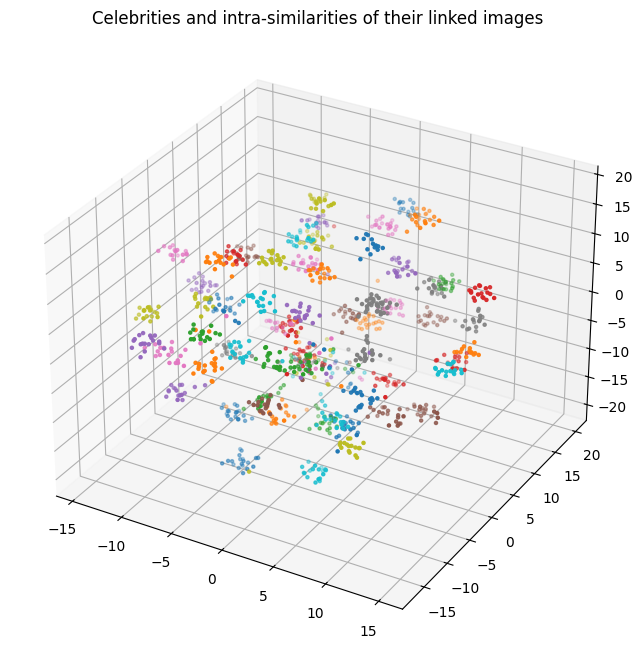

In [ ]:
fig = plt.figure(figsize = (8, 8))
ax = plt.axes(projection = "3d")

for person in person_images.keys():
  points = np.array([item['tsne'] for item in viz if person in item['person']])
  ax.scatter3D(points[:,0], points[:,1], points[:,2], marker ='.') # Indians -> slightly lower inter-similarity to East Asians
plt.title("Celebrities and intra-similarities of their linked images")

# Each celebrity's cluster shown in 2D (one graph per celebrity to measure strength of clustering, or intra-similarity)

In [ ]:
viz = []

# DO T-SNE TO APPROXIMATE ALL IMAGES (STILL PRESERVE THE ID OF THE EMBEDDINGS,
# BUT FOR T-SNE THE ARRAYS ARE FLATTENED TO AGGREGATE TO THE WHOLE SAMPLE SIZE OF ALL IMAGES IN ALL PEOPLE)
for image in X.keys():
  for embed_item in X[image]['facenet512']:
    viz.append({
        "person": image,
        "embedding": embed_item
    })

# AGGREGATE ALL ACHIEVED EMBEDDINGS ACROSS ALL PEOPLE # NOW APPROXIMATING TO 2D
pure_embeddings = np.array([item['embedding'] for item in viz])
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
tsne = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(pure_embeddings)

# LINK THE BATCH TSNE BACK TO EACH PERSON
for i, item in enumerate(viz):
  item["tsne"] = tsne[i]

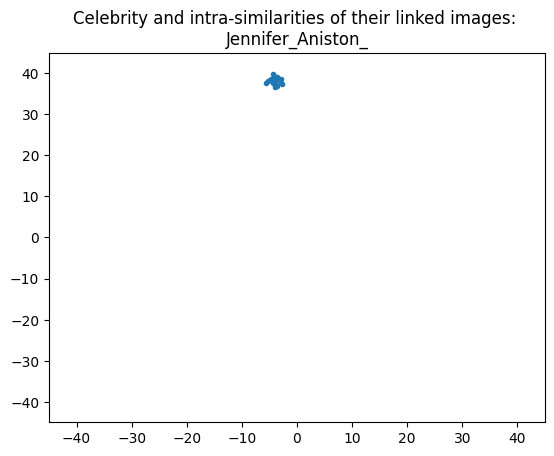

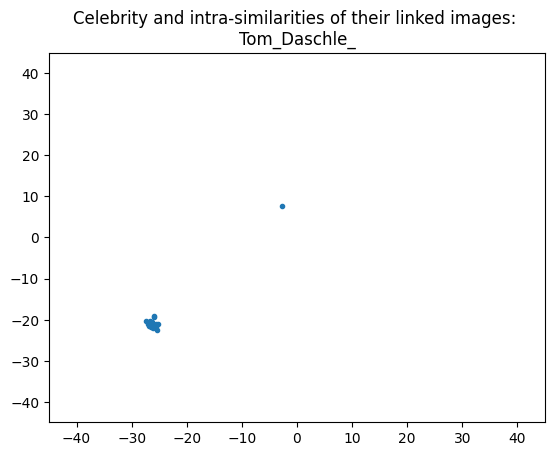

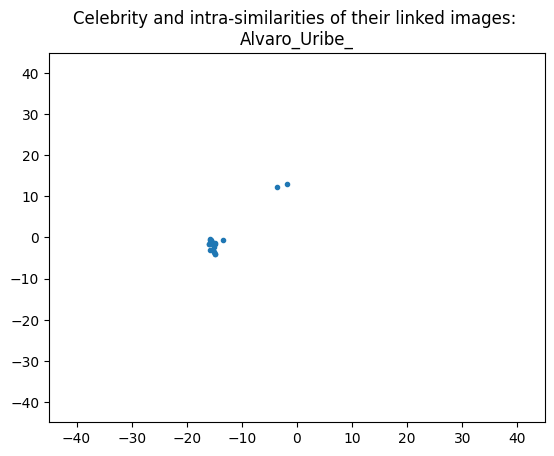

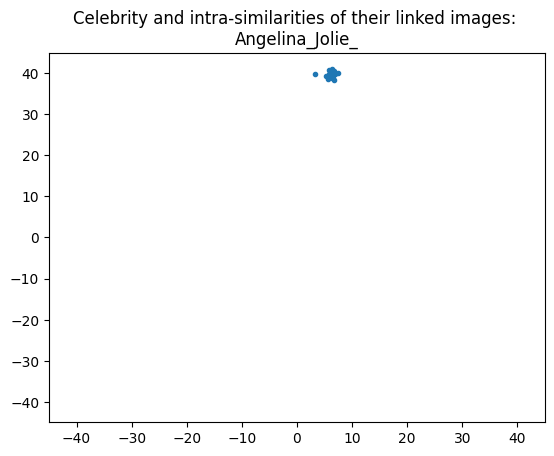

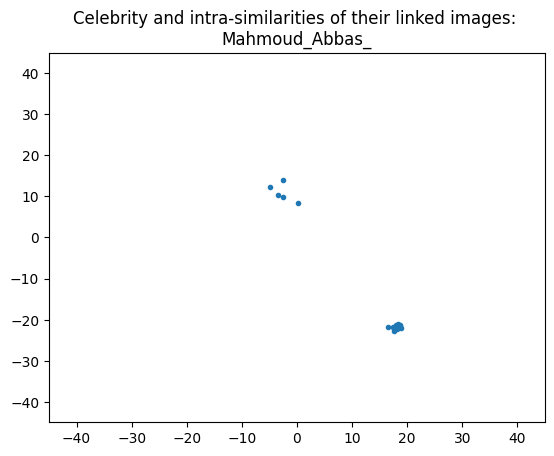

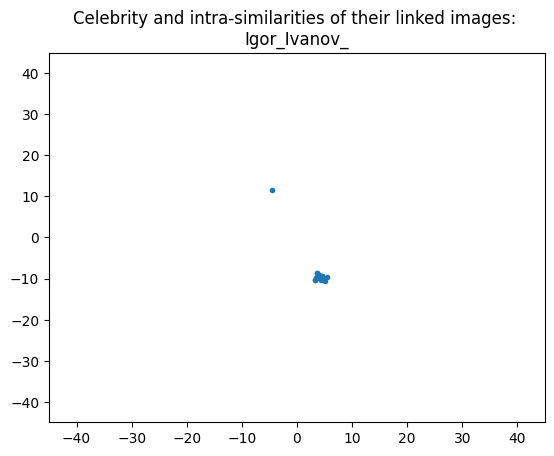

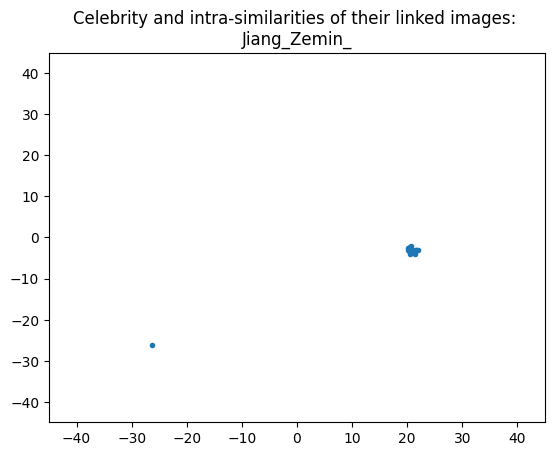

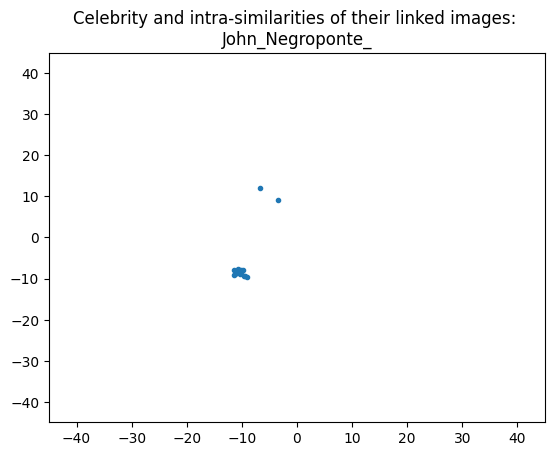

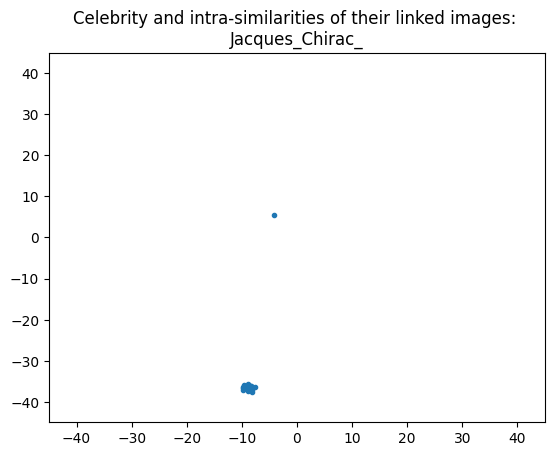

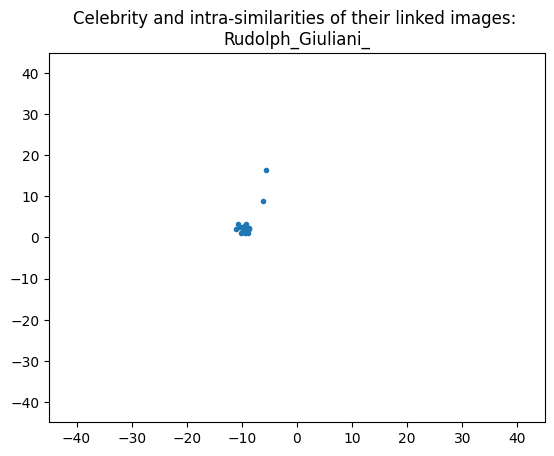

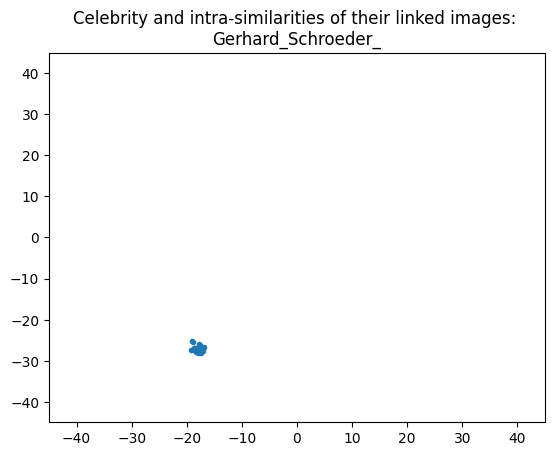

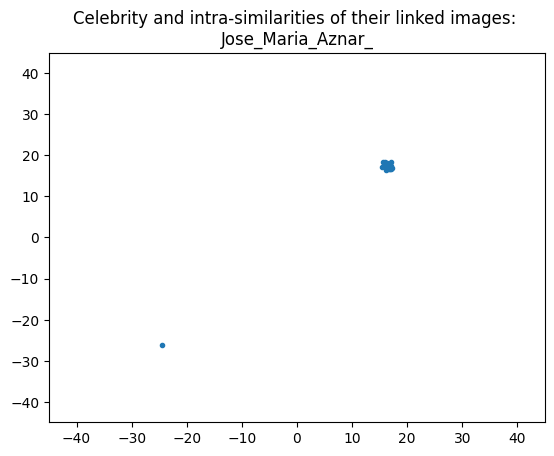

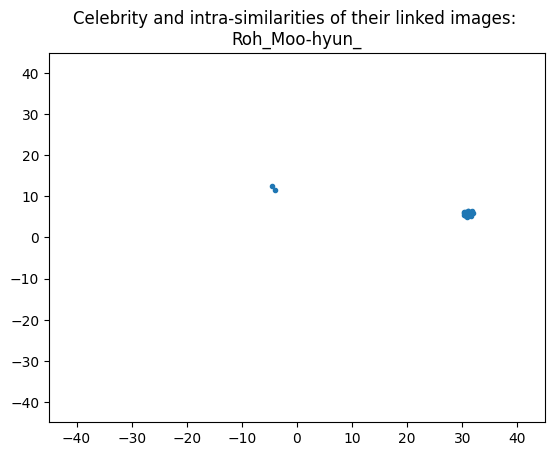

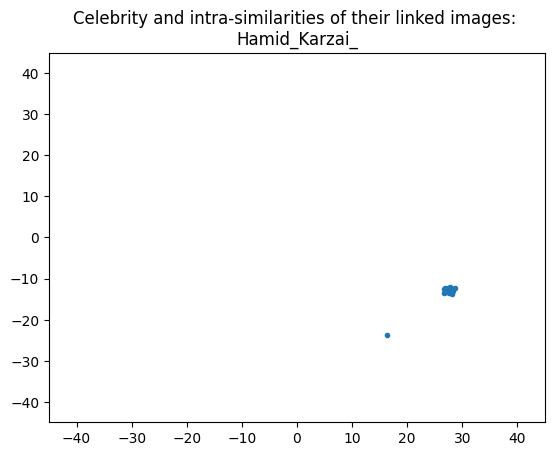

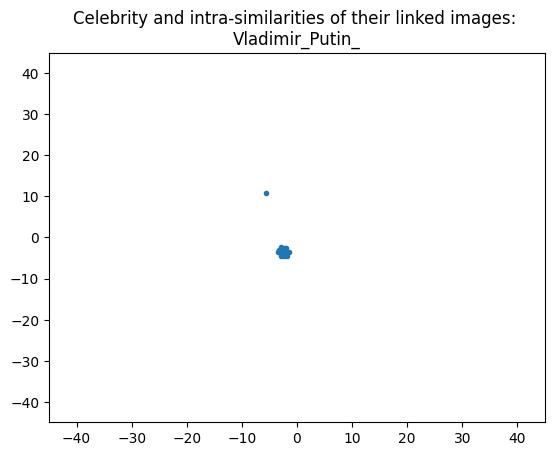

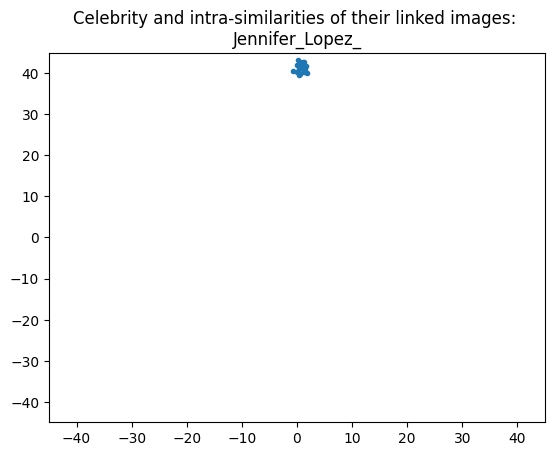

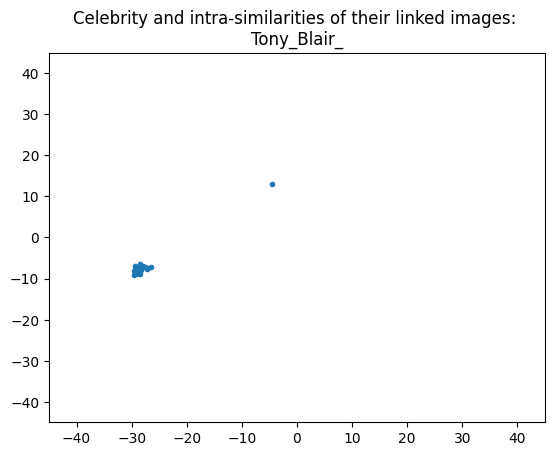

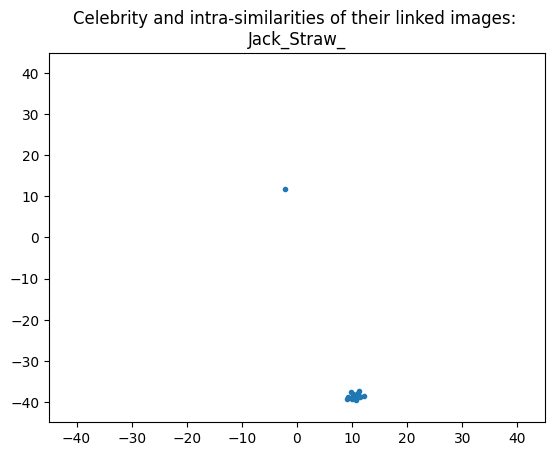

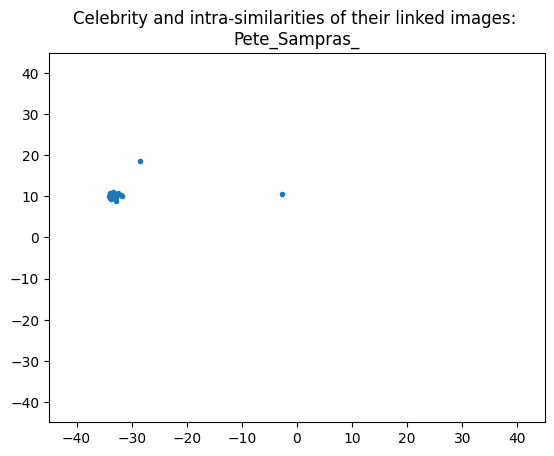

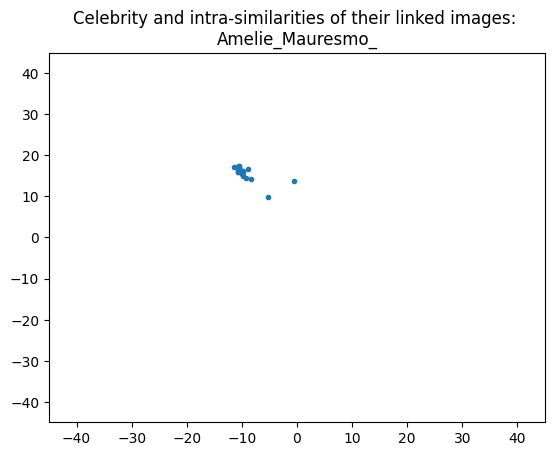

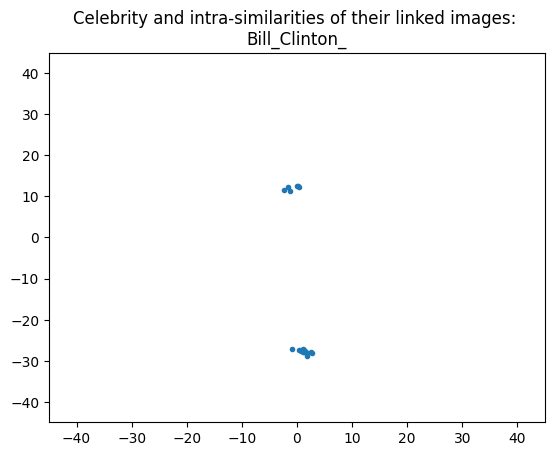

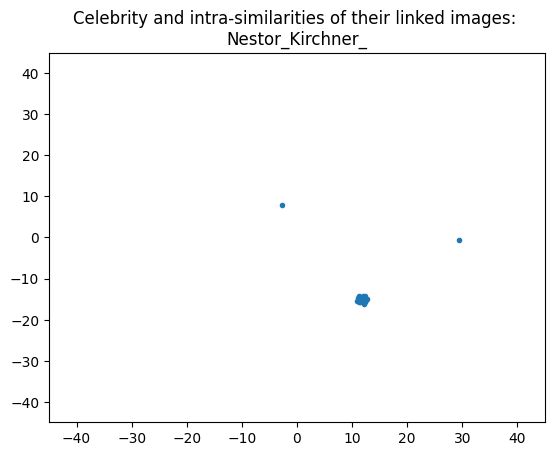

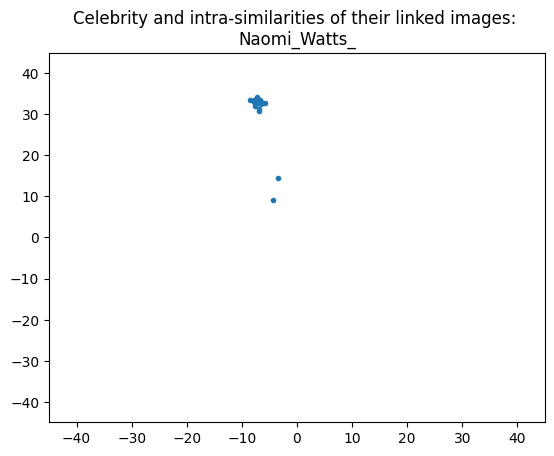

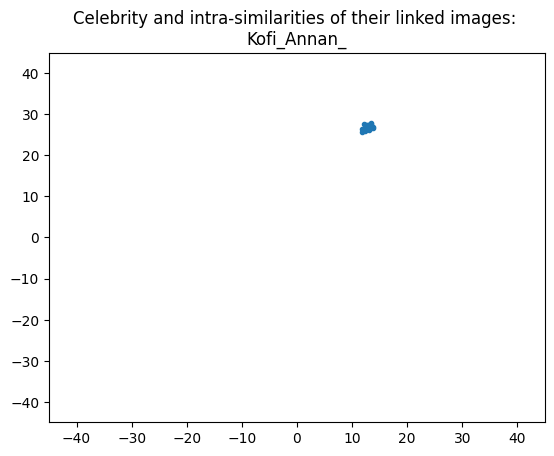

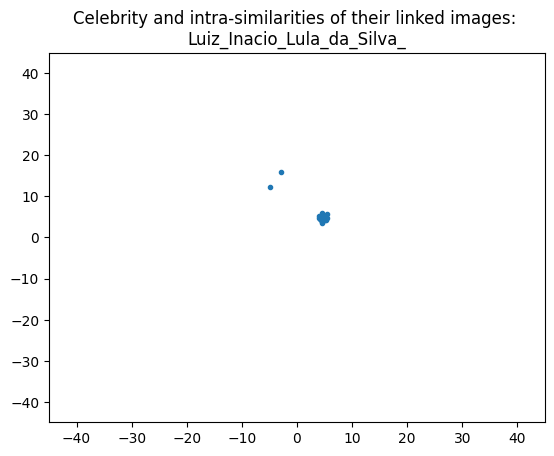

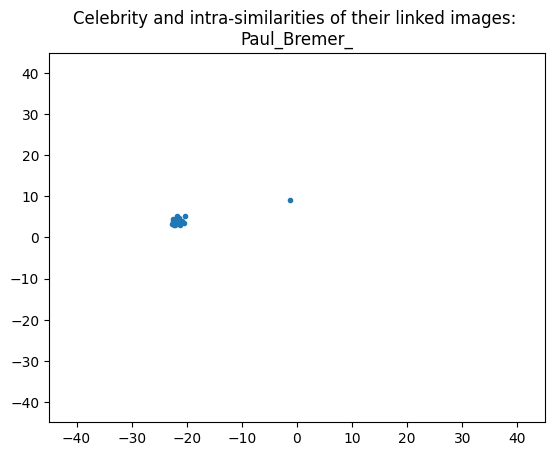

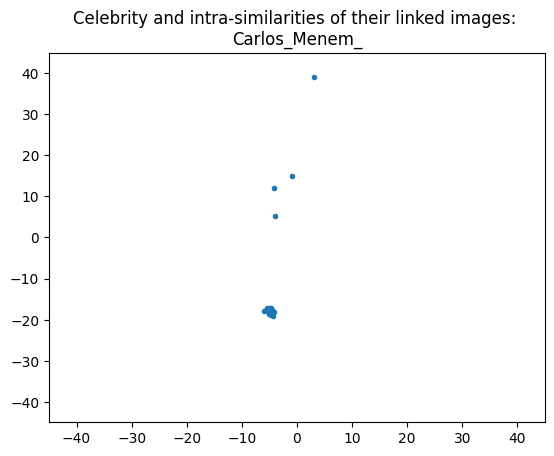

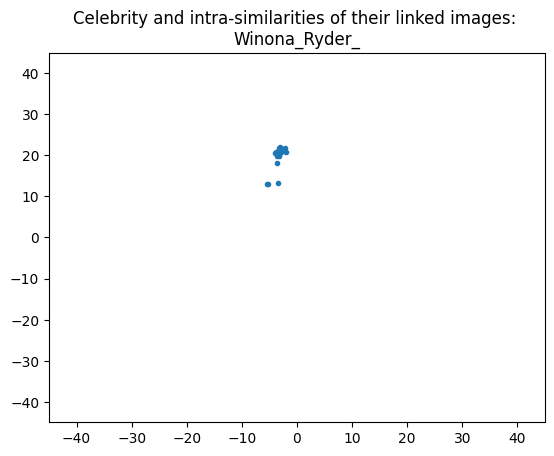

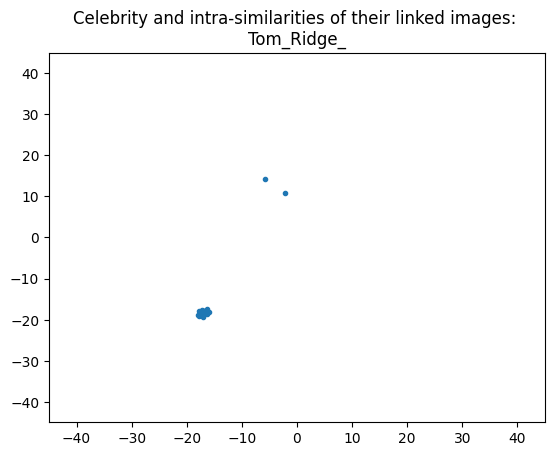

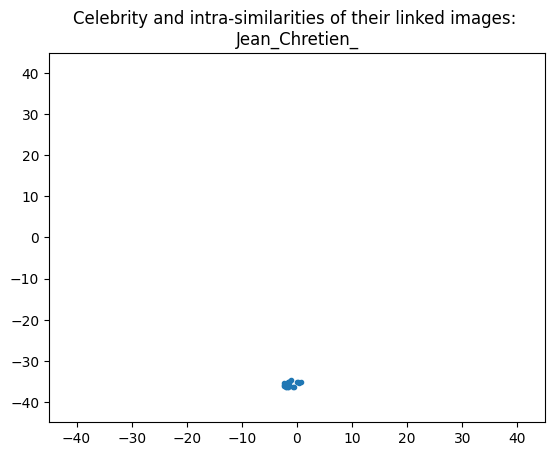

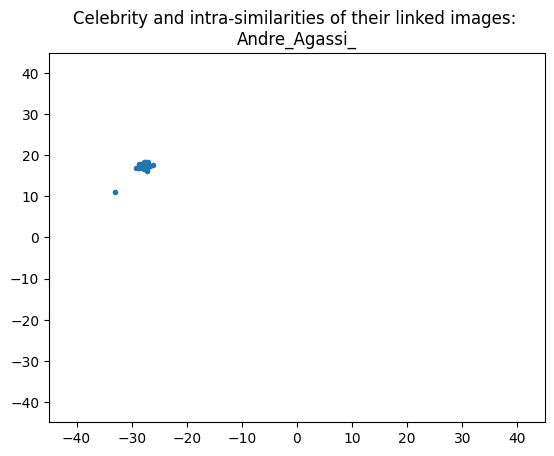

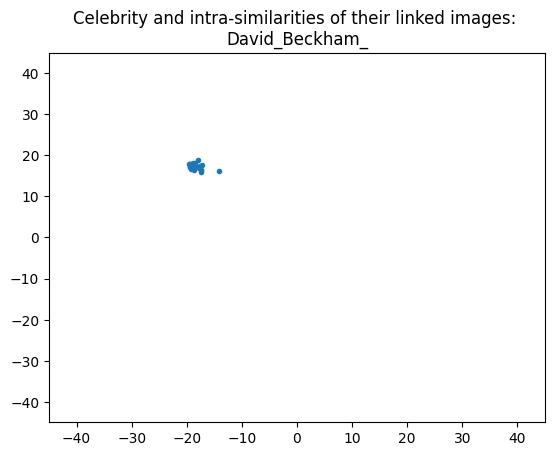

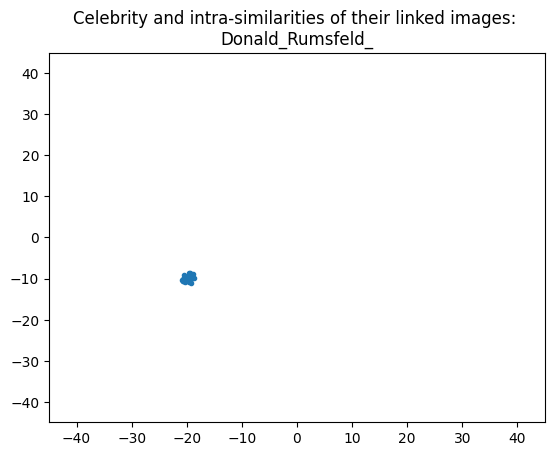

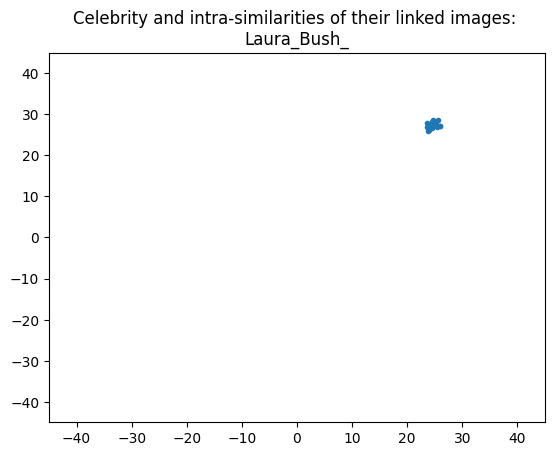

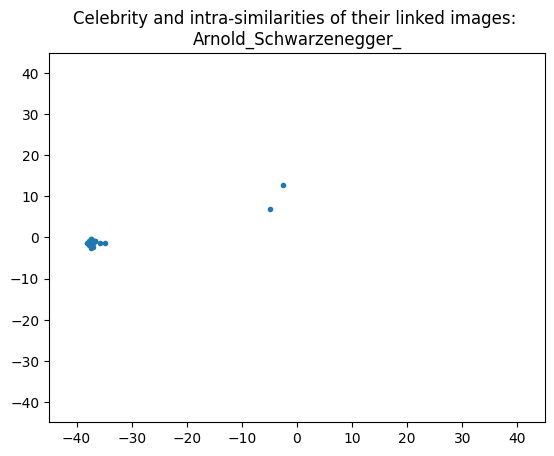

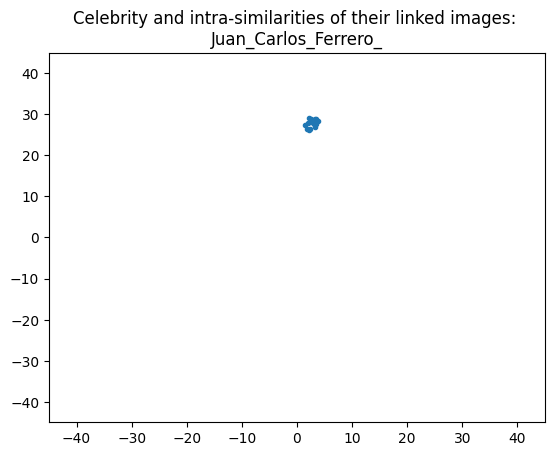

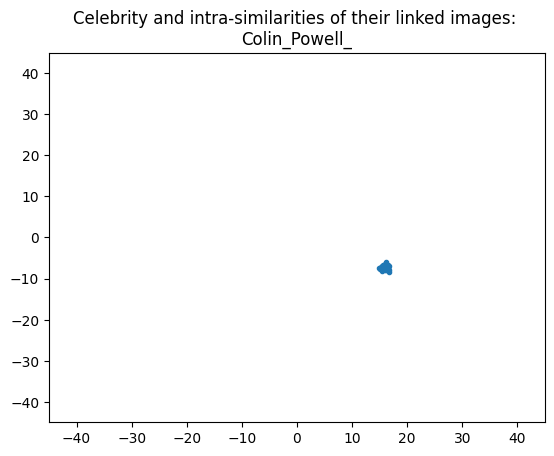

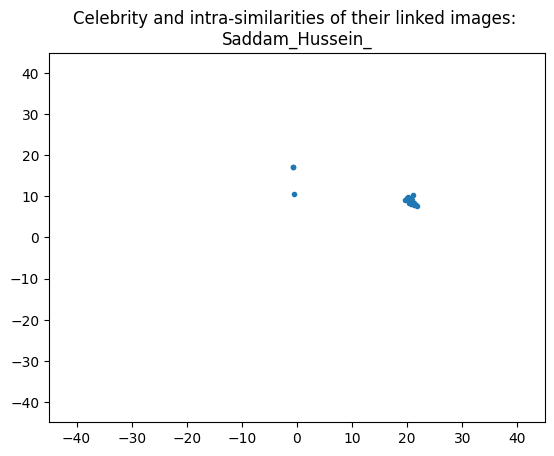

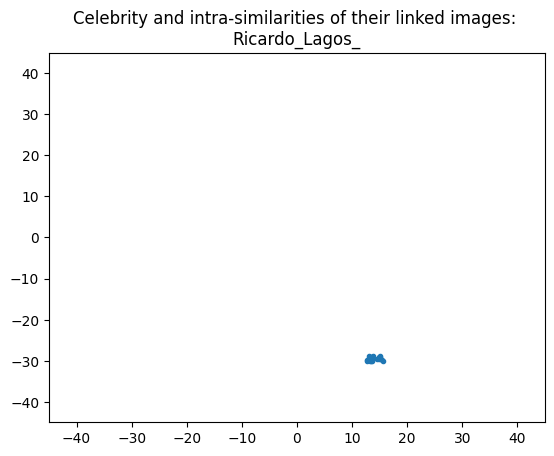

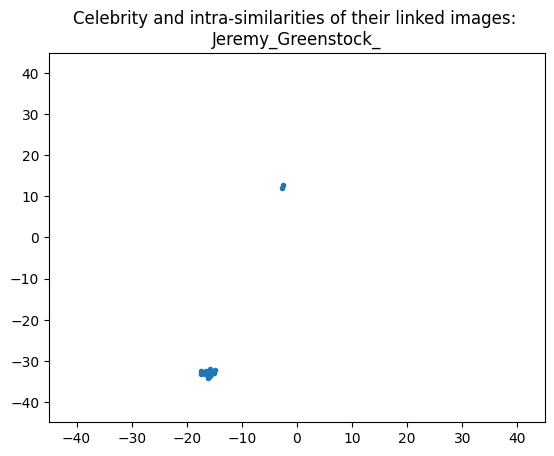

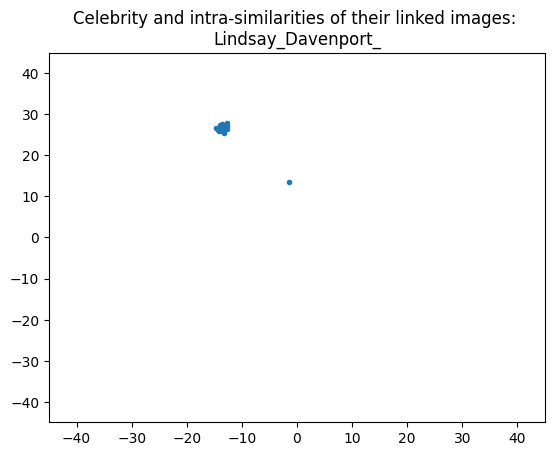

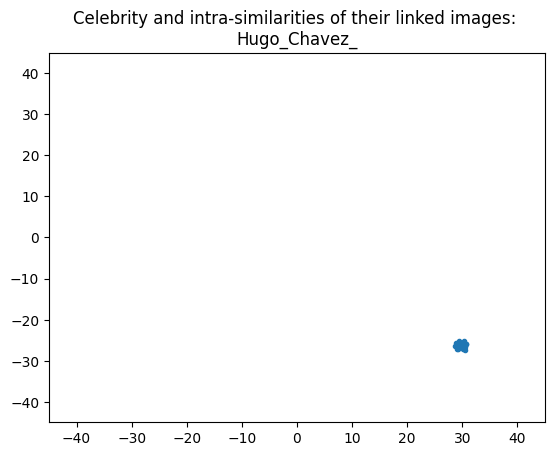

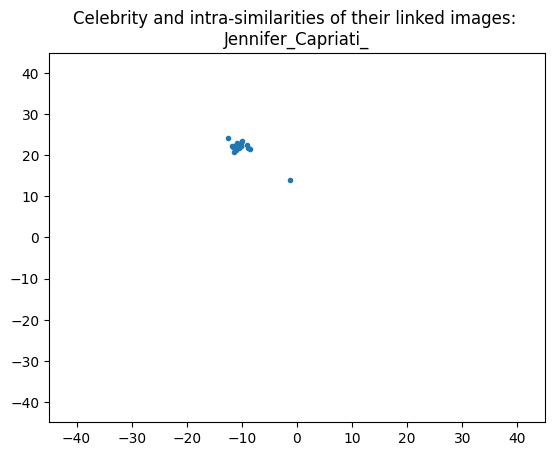

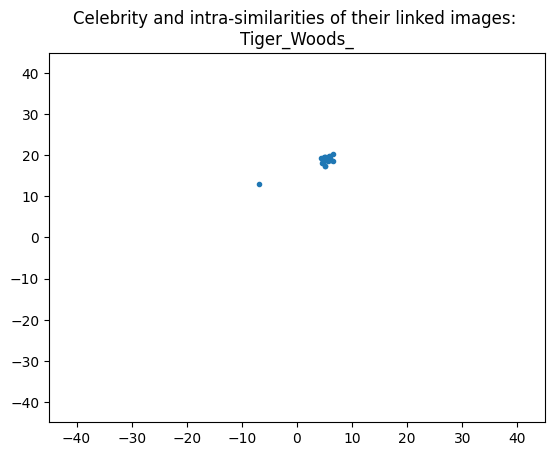

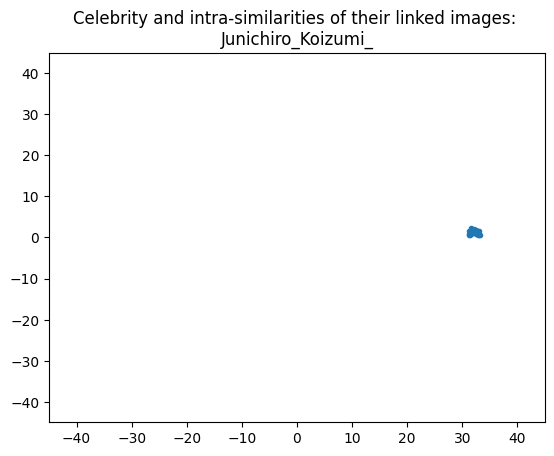

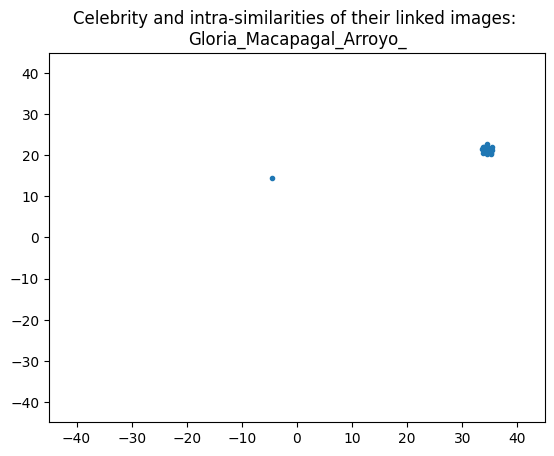

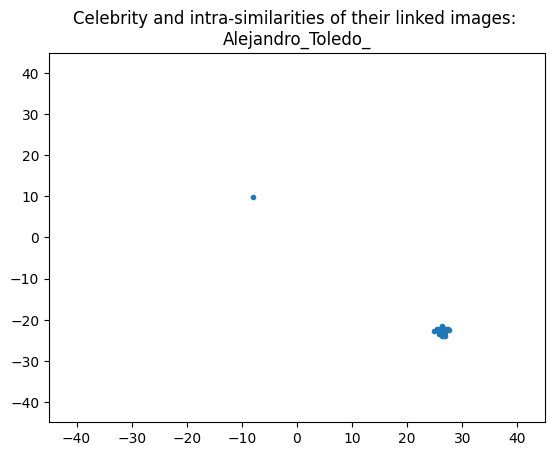

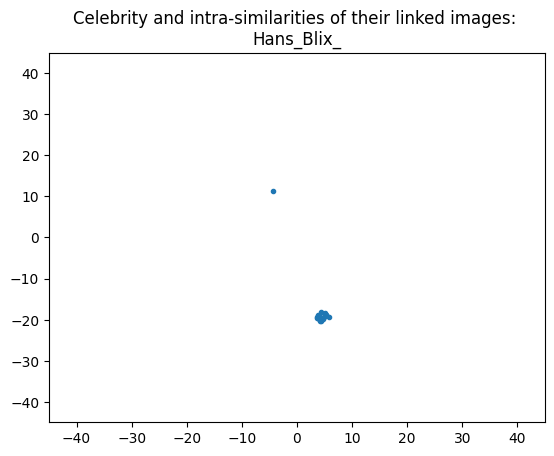

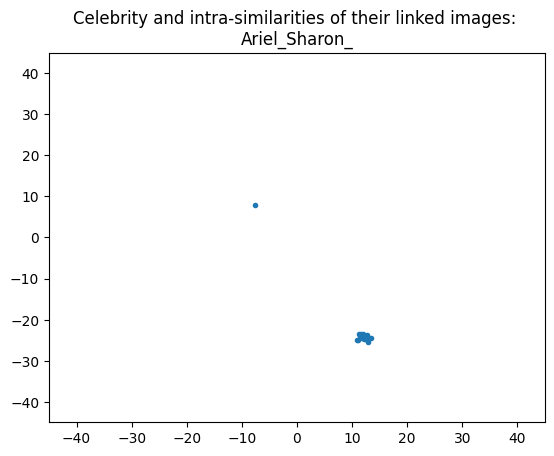

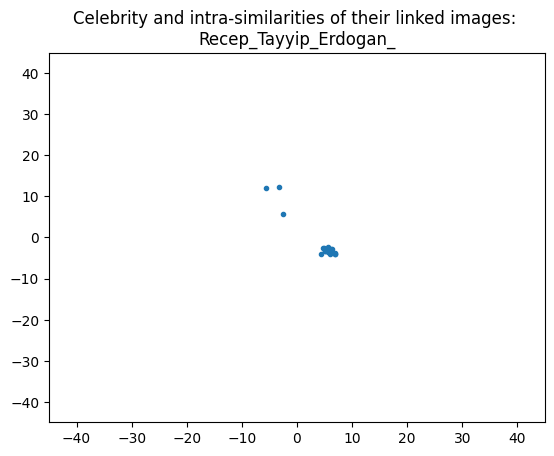

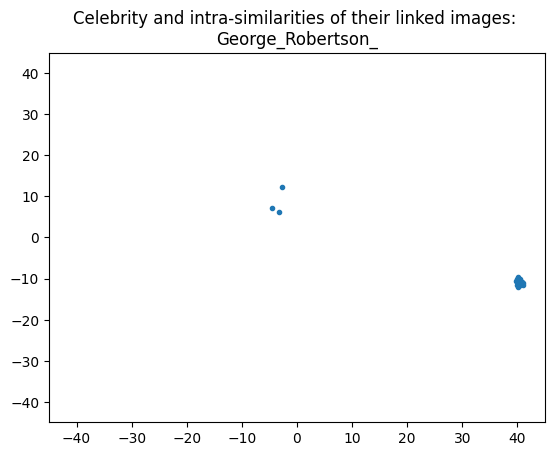

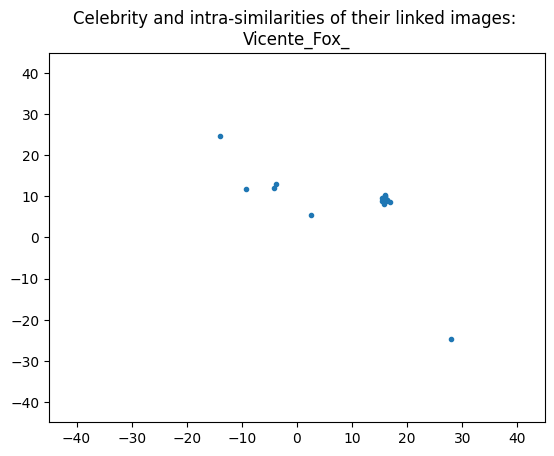

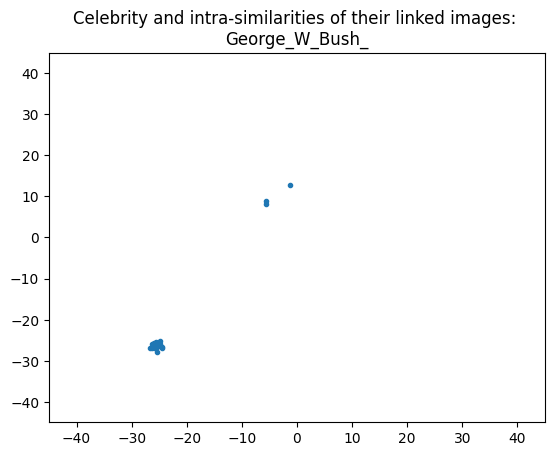

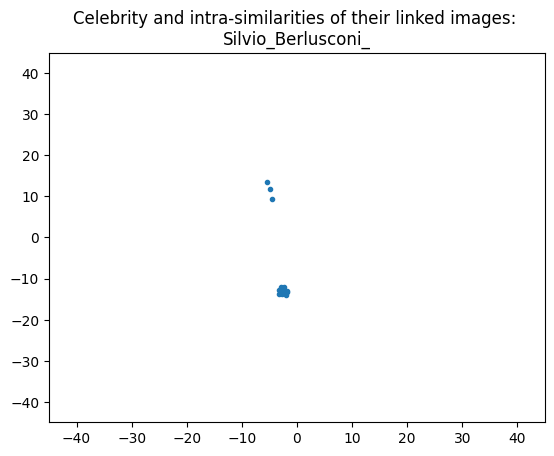

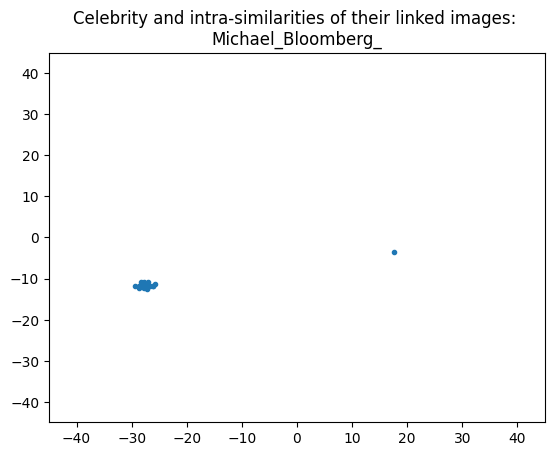

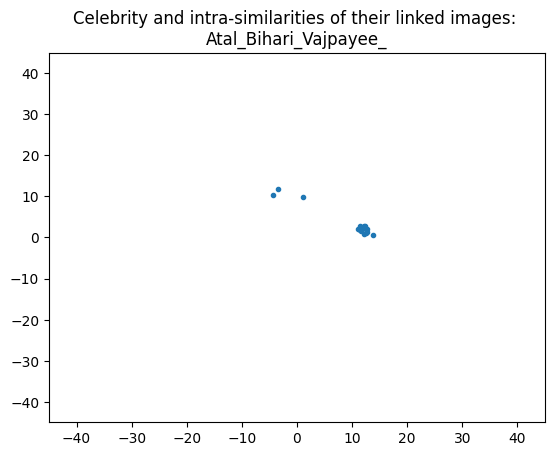

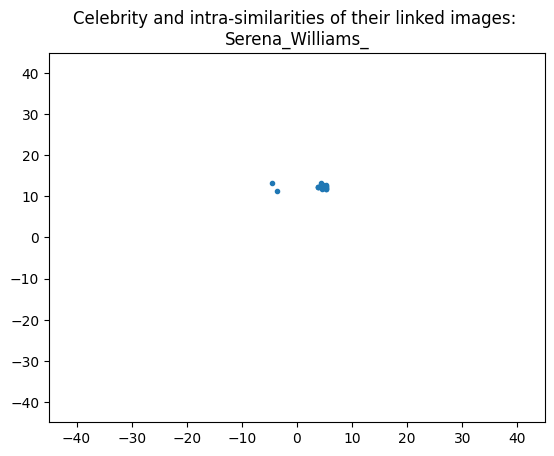

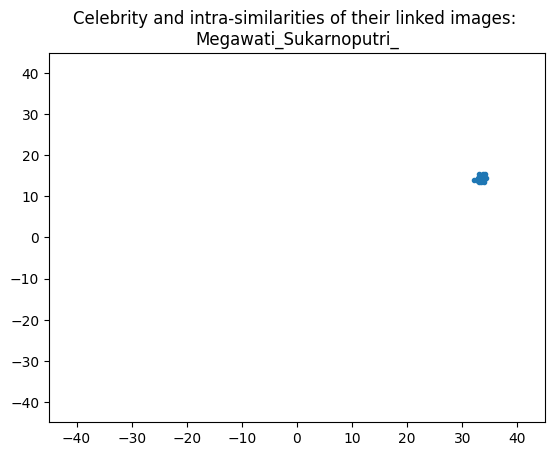

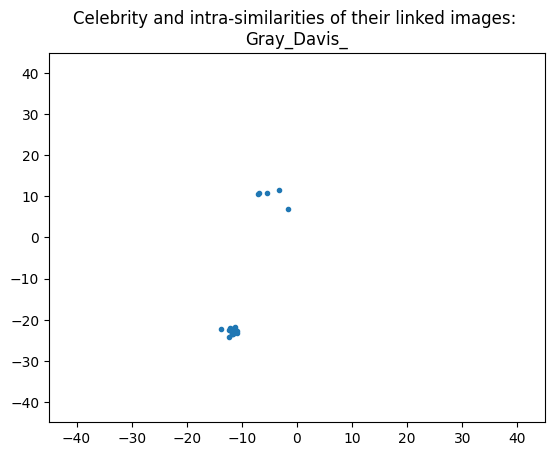

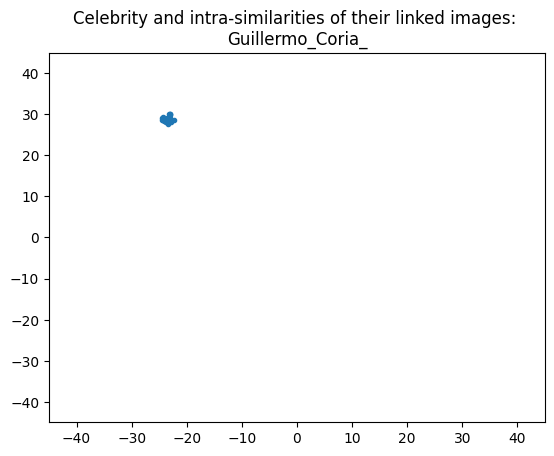

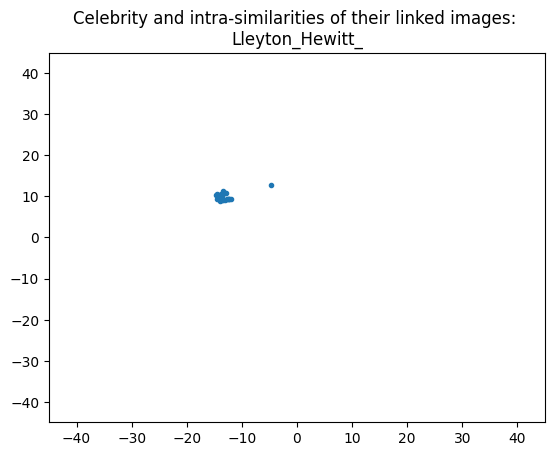

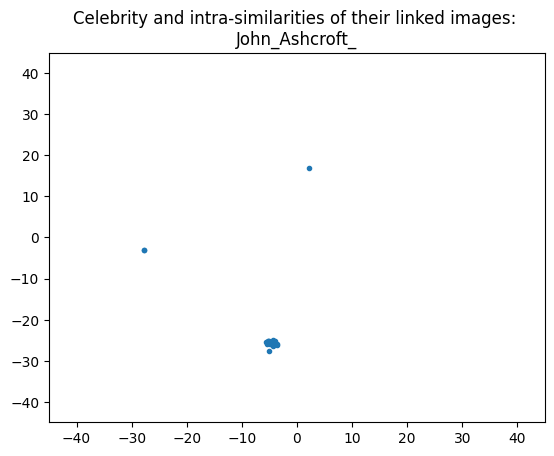

In [ ]:
for person in person_images.keys():
  points = np.array([item['tsne'] for item in viz if person in item['person']])
  plt.xlim(-45, 45)
  plt.ylim(-45, 45)
  plt.scatter(points[:,0], points[:,1], marker ='.') # Indians -> slightly lower inter-similarity to East Asians
  plt.title(f"Celebrity and intra-similarities of their linked images: \n{person}")
  plt.show()

# Detection + Recog (TODO)

In [ ]:
import glob

results = {}
not_recog = []

for detector in ['opencv', 'ssd', 'dlib', 'mtcnn', 'retinaface']:
  for person in person_images.keys():
    for image in glob.glob(f'intra-sim/{person}/*.png'):
      try:
        objs = DeepFace.analyze(
          img_path = image, detector_backend = detector, actions = ['race', 'gender']
        )
        results[f'{detector}/{image.replace("intra-sim/", "").replace("/","-")}'] = objs
      except Exception as e:
        print(f"error with image >>", image, e) # here, detection phase was unsuccessful
        not_recog.append(image)

In [ ]:
### SAVE PROGRESS AS .pickle
with open('tsne-embeddings-lfw.pickle', 'wb') as file_:
    pickle.dump(viz, file_, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
### SAVE PROGRESS AS .pickle
with open('lfw-labelling.pickle', 'wb') as file_:
    pickle.dump(results, file_, protocol=pickle.HIGHEST_PROTOCOL)